Initializing Data Generators...
Generators Ready. Train Batches: 2623, Val Batches: 296

Starting Fusion Model Training...
Epoch 1/50
2622/2623 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.6702 - auc: 0.5922 - loss: 1.3663 - precision: 0.4967 - recall: 0.1157
Epoch 1: val_auc improved from None to 0.71832, saving model to /content/drive/MyDrive/gp_dataset/model_results_v4_fusion/Gatekeeper_Fusion_v4.h5

Epoch 1: finished saving model to /content/drive/MyDrive/gp_dataset/model_results_v4_fusion/Gatekeeper_Fusion_v4.h5
2623/2623 ━━━━━━━━━━━━━━━━━━━━ 417s 155ms/step - accuracy: 0.7000 - auc: 0.6606 - loss: 0.9816 - precision: 0.6088 - recall: 0.1148 - val_accuracy: 0.6660 - val_auc: 0.7183 - val_loss: 0.7171 - val_precision: 0.3024 - val_recall: 0.0103 - learning_rate: 3.0000e-04
Epoch 2/50
2623/2623 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.7475 - auc: 0.7655 - loss: 0.6357 - precision: 0.7172 - recall: 0.3015
Epoch 2: val_auc improved from 0.71832 to 0.72478, saving model to /

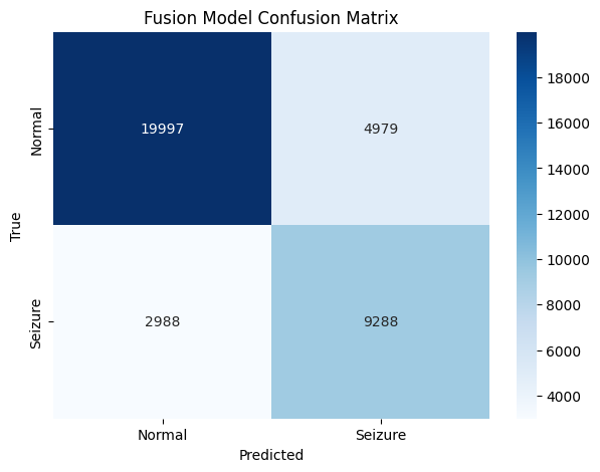

In [ ]:
import os, glob, gc, pickle
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv1D, Conv2D, BatchNormalization, Activation,
                                     MaxPooling1D, GlobalAveragePooling1D, GlobalAveragePooling2D,
                                     Dense, Dropout, Concatenate, GaussianNoise)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint


# SAVE_DIR = '/content/drive/MyDrive/gp_dataset/fusion_raw_and_5x5_v4'
local_path = "/content/local_data/fusion_raw_and_5x5_v4"
RESULTS_DIR = '/content/drive/MyDrive/gp_dataset/model_results_v4_fusion'
os.makedirs(RESULTS_DIR, exist_ok=True)

MODEL_OUT = f'{RESULTS_DIR}/Gatekeeper_Fusion_v4.h5'

class FusionDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, save_dir, split_name, batch_size=128, shuffle=True, **kwargs):
        super().__init__(**kwargs)

        self.save_dir = save_dir
        self.split_name = split_name
        self.batch_size = batch_size
        self.shuffle = shuffle

        self.raw_files = sorted(glob.glob(f'{save_dir}/X_raw_{self.split_name.lower()}_part*.npy'))
        if not self.raw_files:
            self.raw_files = sorted(glob.glob(f'{save_dir}/X_raw_{self.split_name.upper()}_part*.npy'))

        self.eng_files = sorted(glob.glob(f'{save_dir}/X_eng_{self.split_name.lower()}_part*.npy'))
        if not self.eng_files:
            self.eng_files = sorted(glob.glob(f'{save_dir}/X_eng_{self.split_name.upper()}_part*.npy'))

        self.y_files = sorted(glob.glob(f'{save_dir}/y_{self.split_name.lower()}_part*.npy'))
        if not self.y_files:
            self.y_files = sorted(glob.glob(f'{save_dir}/y_{self.split_name.upper()}_part*.npy'))

        if len(self.raw_files) == 0:
            available_files = os.listdir(save_dir)[:5] if os.path.exists(save_dir) else "Directory Not Found"
            raise FileNotFoundError(
                f"error"
            )

        self.file_batch_counts = []
        for yf in self.y_files:
            length = len(np.load(yf, mmap_mode='r'))
            self.file_batch_counts.append(int(np.ceil(length / self.batch_size)))

        self.file_indices = np.arange(len(self.raw_files))
        self.batch_map = []
        self.on_epoch_end()

    def __len__(self):
        return int(sum(self.file_batch_counts))

    def on_epoch_end(self):
        self.batch_map = []
        if self.shuffle:
            np.random.shuffle(self.file_indices)

        for f_idx in self.file_indices:
            num_batches = self.file_batch_counts[f_idx]
            batch_order = np.arange(num_batches)
            if self.shuffle:
                np.random.shuffle(batch_order)
            for b_idx in batch_order:
                self.batch_map.append((f_idx, b_idx))

    def __getitem__(self, index):
        f_idx, b_idx = self.batch_map[index]

        X_raw = np.load(self.raw_files[f_idx], mmap_mode='r')
        X_eng = np.load(self.eng_files[f_idx], mmap_mode='r')
        y_tmp = np.load(self.y_files[f_idx], mmap_mode='r')

        start = b_idx * self.batch_size
        end = start + self.batch_size

        y_batch = np.where(y_tmp[start:end] == 'bckg', 0, 1)

        X_raw_batch = np.array(X_raw[start:end])
        X_eng_batch = np.array(X_eng[start:end])

        return (X_raw_batch, X_eng_batch), y_batch

print("Initializing Data Generators...")
train_gen = FusionDataGenerator(local_path, "train", batch_size=128, shuffle=True)
val_gen = FusionDataGenerator(local_path, "val", batch_size=128, shuffle=False)
test_gen = FusionDataGenerator(local_path, "test", batch_size=128, shuffle=False)

print(f"Generators Ready. Train Batches: {len(train_gen)}, Val Batches: {len(val_gen)}")

def build_fusion_gatekeeper(raw_shape=(1280, 20), eng_shape=(5, 5, 15)):
    input_raw = Input(shape=raw_shape, name="Raw_Input")
    r = GaussianNoise(0.02)(input_raw)
    r = Conv1D(32, 15, strides=2, padding='same', kernel_regularizer='l2')(r)
    r = BatchNormalization()(r)
    r = Activation('relu')(r)
    r = MaxPooling1D(4)(r)
    r = Conv1D(64, 5, padding='same', kernel_regularizer='l2')(r)
    r = BatchNormalization()(r)
    r = Activation('relu')(r)
    r = GlobalAveragePooling1D()(r)

    input_eng = Input(shape=eng_shape, name="Engineered_Input")
    e = Conv2D(16, (1, 1), padding='same', kernel_regularizer='l2')(input_eng)
    e = BatchNormalization()(e)
    e = Activation('relu')(e)
    e = Conv2D(32, (2, 2), padding='valid', kernel_regularizer='l2')(e)
    e = BatchNormalization()(e)
    e = Activation('relu')(e)
    e = GlobalAveragePooling2D()(e)

    merged = Concatenate()([r, e])
    dense = Dense(64, activation='relu', kernel_regularizer='l2')(merged)
    dense = Dropout(0.5)(dense)
    outputs = Dense(1, activation='sigmoid')(dense)

    return Model(inputs=[input_raw, input_eng], outputs=outputs)

model = build_fusion_gatekeeper()
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0003)
model.compile(optimizer=optimizer, loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                       tf.keras.metrics.Precision(name='precision'),
                       tf.keras.metrics.Recall(name='recall')])


callbacks = [
    EarlyStopping(monitor='val_auc', patience=8, restore_best_weights=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=4, min_lr=1e-6, mode='max', verbose=1),
    ModelCheckpoint(MODEL_OUT, monitor='val_auc', save_best_only=True, mode='max', verbose=1)
]

print("\nStarting Fusion Model Training...")
history = model.fit(train_gen, validation_data=val_gen, epochs=50, callbacks=callbacks, verbose=1)


print("\nEvaluating on Validation Set...")
probs_val = model.predict(test_gen).flatten()

y_val_true = []
for yf in test_gen.y_files:
    y_val_true.extend(np.where(np.load(yf) == 'bckg', 0, 1))
y_val_true = np.array(y_val_true)

fpr, tpr, thresholds = roc_curve(y_val_true, probs_val)
optimal_threshold = thresholds[np.argmax(tpr - fpr)]
preds_val = (probs_val > optimal_threshold).astype(int)

print(f"\nOptimal Threshold: {optimal_threshold:.4f}")
print("\nClassification Report:")
print(classification_report(y_val_true, preds_val, target_names=['Normal', 'Seizure']))

plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_val_true, preds_val), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Seizure'], yticklabels=['Normal', 'Seizure'])
plt.title('Fusion Model Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()